# Constrained Optimization Theory

In this section, we'll examine constrained optimization problems that take the form

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & f(x) \\
\text{such that} \qquad & c(x) \le 0 \\
\end{aligned}
\end{equation*}

The objective function $f : \mathbb{R}^{n} \rightarrow \mathbb{R}$, remains a scalar function of the design variables $x \in \mathbb{R}^n$.
The new part of this optimization problem is the inequality constraints $c(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}^{m}$.
Here the inequality $c(x) \le 0$ means that each constraint $c_{i}(x) \le 0$ for $i = 1,\ldots,m$.

A design point $x$ that satisfies all the inequality constraints so that $c(x) \le 0$ is called a *feasible point*.
a design point $x$ where one or more constraints is violated such that $c_{i}(x) > 0$ for some $i$, is called an *infeasible point*.

All of our theory will be derived from the cannonical example above where we express the inequality constraints as $c(x) \le 0$.
If the optimizaiton problem is not in this form, then key results will not apply!

In this section, we focus on inequality constraints.
Many practical problems also contain equality constraints that can be separated to give a more detailed problem statement 

\begin{equation*}
\begin{aligned}
\min_{x} \qquad & f(x) \\
\text{such that} \qquad & c(x) \le 0 \\
& h(x) = 0 \\
\end{aligned}
\end{equation*}

where $h(x) = 0$ are the equality constraints.
It turns out that equality constraints are easier to handle compared to inequalities.
We will focus on the original problem, and only look at the end at equality constraints.
(Note that we could treat $h(x) = 0$ as $h(x) \le 0$ and $-h(x) \le 0$.)

In this section, we'll work with the gradient of the objective $\nabla f$ as well as the gradients of the constraints.
Our standing assumption will again be that these are smooth functions that we can differentiate as many times as needed.
The constraint Jacobian matrix, $A(x)$, will play an important role in the theory of constrained optimization.
The constraint Jacobian is defined as

\begin{equation*}
A_{ij} = \dfrac{\partial c_{i}}{\partial x_{j}}
\end{equation*}

As a result, the i-th row of the matrix $A$ consists of the entries of the gradient of $c_{i}$.
If $e_{k}$ is the k-th Cartesian basis vector, with a $1$ in the k-th entry and zero in all others then:

\begin{equation*}
\nabla c_{k} = A(x)^{T} e_{k}
\end{equation*}

The objective of this section is to establish a theory for constrained optimization that is analogous to the theory that we developed for unconstrained optimization.
Recall from the theory of unconstrained optimization that we have the following conditions:

1. Necessary conditions: Local minimizer has $\nabla f(x^{*}) = 0$ and $H(x^{*})$ positive semi-definite
2. Sufficient conditions: If $\nabla f(x^{*}) = 0$ and $H(x^{*})$ is positive definite then $x^{*}$ is a minimizer

These conditions will be a special case of the general Karush-Kuhn-Tucker conditions for constrained optimization.

## Active constraints

One key concept in constrained optimization is the *active set*.
The active set is the set of constraints that are at their bound at a point.
The active set can be defined formally as the set of indices that satisfy the following property

\begin{equation*}
\mathcal{A}(x) = \left\{ \; i \; | \; c_{i}(x) = 0 \; \right\}
\end{equation*}

A particularly important active set, is the active set at the minimizer given by

\begin{equation*}
\mathcal{A}^{*} = \left\{ \; i \; | \; c_{i}(x^{*}) = 0 \; \right\}
\end{equation*}

If we knew what the active set at $x^{*}$ was at the beginning of the optimization problem, we could elminate the remaining constraints and treat the constraints in the active set as equalities.
This modified problem, with only equalities, would give us the correct solution of the inequality constrained problem.
However, in practice, we won't know what $\mathcal{A}^{*}$ is until we solve the problem.
Inequality constrained problems are therefore more challenging, because we have to combine solving a nonlinear optimization problem with a combinatorial problem of determining which constraints are important.
Some computational methods work directly with an approximation of the active set, typically referred to as the working set or active set.
Other constrained optimization methods avoid the issue of the active set by utilizing a penalty method. 
Nonetheless, the active set plays an important role in the analysis of these methods as well.

## Descent and Feasible directions

To understand the first-order necessary conditions for constrained optimization, consider the design point $x$ in the design space.
From $x$, we can move along any direction $d$ to another design point $x + d$.

Consider first the objective. A linearization of the objective function will tell us whether the function is increasing or decreasing along the direction $d$:

\begin{equation*}
f(x+d) \approx f(x) + d^{T} \nabla f
\end{equation*}

A descent direction of the function $f(x)$ satisfies the relationship $d^{T}\nabla f < 0$. Note here that we are not content with just the same value of $f(x)$, so we restrict the direction $d$ so that it must strictly decrease.
This gives the set of descent directions as the cone

\begin{equation*}
\mathcal{D} = \left\{ \; d \in \mathbb{R}^{n} \; | \; d^{T}\nabla f < 0 \; \right\}
\end{equation*}

Any direction $d \in \mathcal{D}$ is a descent direction.
In the abscence of any constraints, we are free to pick any descent direction we want.
However, when we are on a constraint boundary, we can no longer move into the infeasible space, so our step is restricted.

The applet below can be used to visualize how the descent and feasible direction sets change as the current point, indicated by the black dot, is varied for the Rosenbrock function.  

### Adding one constraint

Consider a constrained problem with a single constraint $c_{1}(x) \le 0$.
When the point $x$ is at the constraint boundary, $c_{1}(x) = 0$.
As a result of the step along the direction $d$, we have that

\begin{equation*}
c_{1}(x+d) \approx c_{1}(x) + d^{T} \nabla c_{1} = d^{T} \nabla c_{1}
\end{equation*}

For the new point $x + d$ to remain feasible, we must have that $c_{1}(x+d) \approx d^{T} \nabla c_{1} \le 0$.
As a result, the feasible directions should satisfy

\begin{equation*}
\mathcal{F} = \left\{ \; d \in \mathbb{R}^{n}  \; | \; - d^{T} \nabla c_{1} \ge 0 \; \right\}
\end{equation*}

From $x$, we should move along a descent direction $d$ so that it is both a descent direction $d \in \mathcal{D}$ and a feasible direction $d \in \mathcal{F}$.
As a result, the direction $d$ should be in the intersection between $\mathcal{D}$ and $\mathcal{F}$ so that

\begin{equation*}
d \in \mathcal{D} \cap \mathcal{F}
\end{equation*}

### The Cones of Constrained Optimizaiton

Now let's add more constraints to the design problem.
Consider the case when we have both $c_{1}(x) = 0$ and $c_{2}(x) = 0$ at the current design point $x$.
Now our feasible steps will be more restricted so that both $c_{1}$ and $c_{2}$ have to be taken into account

\begin{equation*}
\mathcal{F} = \left\{ \; d \in \mathbb{R}^{n}  \; | \; - d^{T} \nabla c_{1} \ge 0 \;\;  - d^{T} \nabla c_{2} \ge 0 \right\} = \mathcal{F}_{1} \cap \mathcal{F}_{2} 
\end{equation*}

In general, we will have to consider all constraints that are active at the point $x$, so that our 

\begin{equation*}
\mathcal{F} = \left\{ \; d \in \mathbb{R}^{n} \; | \; - d^{T} \nabla c_{i} \ge 0 \;\;\; \forall i \in \mathcal{A}(x) \; \right\}
\end{equation*}

The set of directions $\mathcal{D}$ and $\mathcal{F}$ are called the descent and feasible cones.


### Examples

To motivate the theory that we're going to see, consider the following simple constrained optimization problems:
<!-- 
\begin{equation*}
\begin{aligned}
\min \qquad & x_{1} + x_{2} \\
\text{such that} \qquad & x_{1}^{2} + x_{2}^{2} - 2 = 0
\end{aligned}
\end{equation*} -->

\begin{equation*}
\begin{aligned}
\min \qquad & x_{1} + x_{2} \\
\text{such that} \qquad & x_{1}^{2} + x_{2}^{2} - 2 \le 0 \\
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
\min \qquad & x_{1} + x_{2} \\
\text{such that} \qquad & x_{1}^{2} + x_{2}^{2} - 2 \le 0 \\
& -x_{2} \le 0
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
\min \qquad & x_{1} \\
\text{such that} \qquad & x_{1}^{2} + x_{2}^{2} - 2 \le 0 \\
& -x_{2} \le 0
\end{aligned}
\end{equation*}

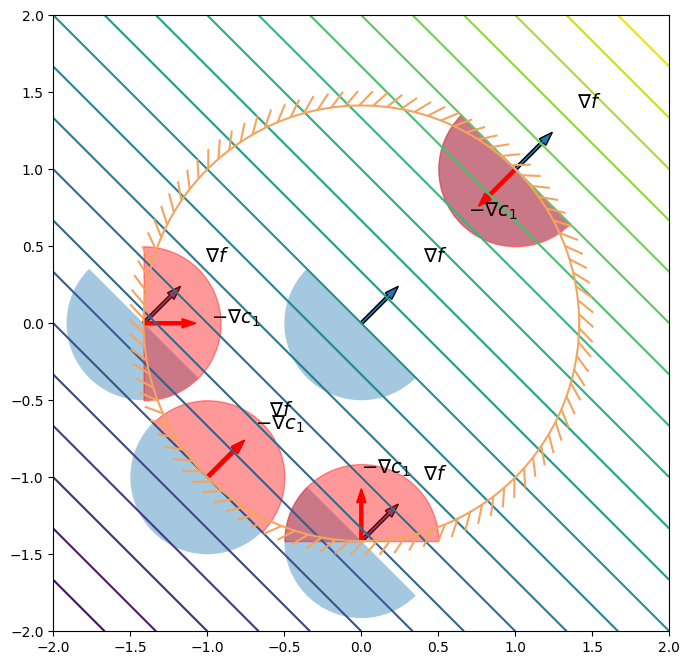

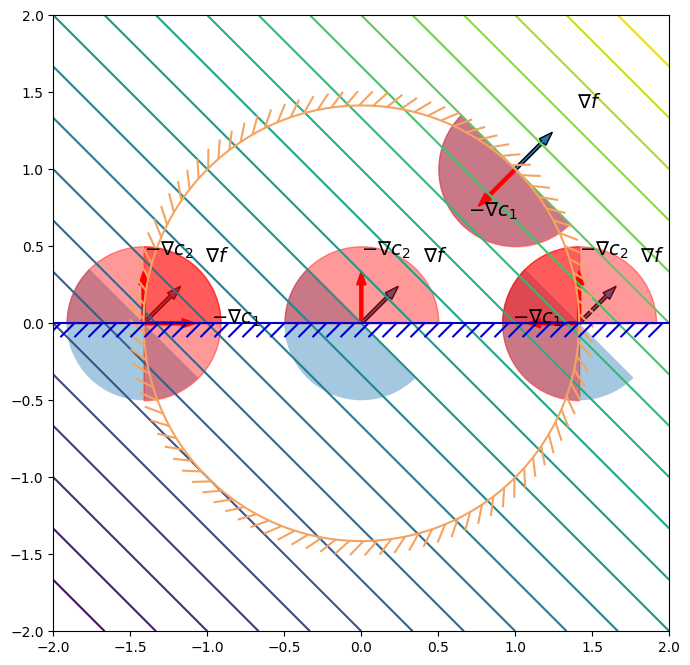

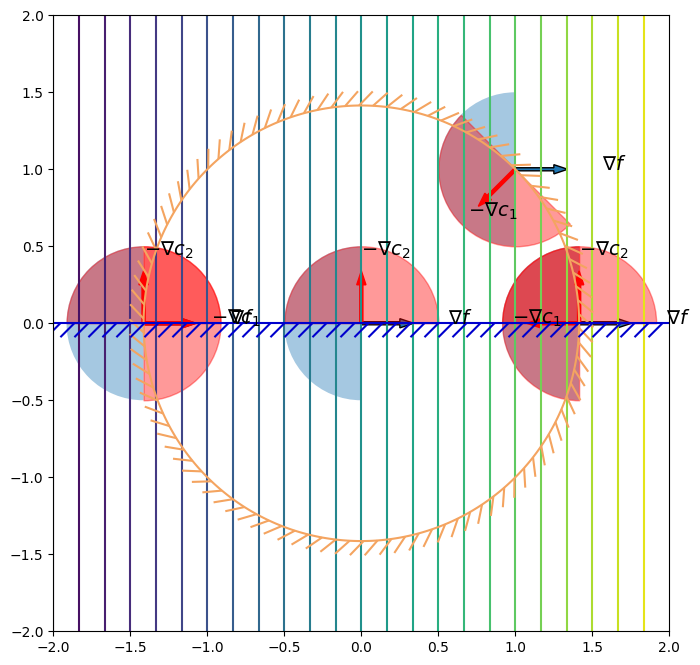

In [1]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection
from matplotlib import patheffects

def plot_contour(func, xlow=-2, xhigh=2,
                 ylow=-2, yhigh=2, n=200, nonlinear=False):
    """Create a contour plot of the function"""
    
    # Plot the contours of the function
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = [X[i, j], Y[i, j]]
            f[i, j] = func(x)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    levels = np.linspace(np.min(f), np.max(f), 25)
    if nonlinear:
        levels = np.min(f) + (np.max(f) - np.min(f))*np.linspace(0, 1.0, 25)**2
    ax.contour(X, Y, f, levels=levels)
    ax.set_aspect('equal', 'box')
    
    return fig, ax

def plot_constraint(ax, con, xlow=-2, xhigh=2,
                    ylow=-2, yhigh=2, n=200, **kwargs):
    """Create a contour plot of the function"""
    
    # Plot the contours of the function
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    c = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = [X[i, j], Y[i, j]]
            c[i, j] = con(x)

    c1 = ax.contour(X, Y, c, [0.0], **kwargs)
    plt.setp(c1, path_effects=[patheffects.withTickedStroke()])
    
    return

def plot_descent(x0, grad, ax):
    """
    Plot the descent directions from the point x0 along the gradient direction grad
    """
    
    # Calculate a descent direction with a reasonable scale
    # Use the scale of -1 to draw the right cone
    p = -0.25*grad/np.sqrt(np.dot(grad, grad))
    
    # Plot the scaled gradient direction
    ax.arrow(x0[0], x0[1], -p[0], -p[1], width=0.02)
    
    # Plot the semi-circle of descent directions
    r = 0.5
    t1 = 180.0*np.arctan2(-p[0], p[1])/np.pi
    t2 = 180.0*np.arctan2(p[0], -p[1])/np.pi
    wedge = Wedge((x0[0], x0[1]), r, t1, t2)
    collection = PatchCollection([wedge], alpha=0.4)
    ax.add_collection(collection)
    
    # Draw the arrow in the proper gradient direction
    ax.text(x0[0] - 2.25*p[0], x0[1] - 2.25*p[1], r'$\nabla f$', size=14)
    
    return

def plot_feasible(x0, grad, ax, index=1):
    """
    Plot the feasible directions from the point x0
    """
    
    # Calculate the direction with a reasonable scale
    p = -0.25*grad/np.sqrt(np.dot(grad, grad))
    
    # Plot the scaled gradient direction
    ax.arrow(x0[0], x0[1], p[0], p[1], width=0.02, color='r')
    
    # Plot the semi-circle of descent directions
    r = 0.5
    t1 = 180.0*np.arctan2(-p[0], p[1])/np.pi
    t2 = 180.0*np.arctan2(p[0], -p[1])/np.pi
    wedge = Wedge((x0[0], x0[1]), r, t1, t2, color='r')
    collection = PatchCollection([wedge], alpha=0.4, color='r')
    ax.add_collection(collection)
    ax.text(x0[0] + 1.75*p[0], x0[1] + 1.75*p[1], r'$-\nabla c_{%d}$'%(index), size=14)
    
    return

def f1(x):
    return x[0] + x[1]

def grad_f1(x):
    return np.array([1, 1])

def f2(x):
    return x[0]

def grad_f2(x):
    return np.array([1, 0])
    
def c1(x):
    return x[0]**2 + x[1]**2 - 2

def grad_c1(x):
    return np.array([2*x[0], 2*x[1]])

def c2(x):
    return -x[1]

def grad_c2(x):
    return np.array([0.0, -1.0])

tol = 1e-6
r2 = np.sqrt(2)
x0vals = [[0, 0], [-1, -1], [0, -r2],  [-r2, 0], [1, 1]]

fig, ax = plot_contour(f1)
for x0 in x0vals:
    plot_descent(x0, grad_f1(x0), ax)

    c = c1(x0)
    if np.fabs(c) < tol:
        plot_feasible(x0, grad_c1(x0), ax)

plot_constraint(ax, c1, colors='sandybrown')

x0vals = [[0, 0], [-r2, 0], [1, 1], [r2, 0]]

fig, ax = plot_contour(f1)
for x0 in x0vals:
    plot_descent(x0, grad_f1(x0), ax)

    c = c1(x0)
    if np.fabs(c) < tol:
        plot_feasible(x0, grad_c1(x0), ax)
    c = c2(x0)
    if np.fabs(c) < tol:
        plot_feasible(x0, grad_c2(x0), ax, index=2)

plot_constraint(ax, c1, colors='sandybrown')
plot_constraint(ax, c2, colors='mediumblue')

fig, ax = plot_contour(f2)
for x0 in x0vals:
    plot_descent(x0, grad_f2(x0), ax)

    c = c1(x0)
    if np.fabs(c) < tol:
        plot_feasible(x0, grad_c1(x0), ax)
    c = c2(x0)
    if np.fabs(c) < tol:
        plot_feasible(x0, grad_c2(x0), ax, index=2)

plot_constraint(ax, c1, colors='sandybrown')
plot_constraint(ax, c2, colors='mediumblue')

plt.show()

In [2]:
from IPython.display import display, HTML

def geogebra_applet(material_id, div_id):
    html_code = f""" 
    <div id="{div_id}" style="width: 400px; height: 300px;"></div>
    <script>
        (function() {{
            var script = document.createElement('script');
            script.src = "https://www.geogebra.org/apps/deployggb.js";
            script.onload = function() {{
                var params = {{"material_id": "{material_id}", "showFullScreenButton": true}};
                var applet = new GGBApplet(params, true);
                applet.inject('{div_id}');
            }};
            document.body.appendChild(script);
        }})();
    </script>
    """
    return HTML(html_code)

# Correct usage of display
display(geogebra_applet("grhrmtnr", "ggb-element-1"))
display(geogebra_applet("uhqk29hm", "ggb-element-2"))  # Replace with another GeoGebra material ID


### How to construct the first-order necessary conditions

If $x$ is a local constrained minimizer, then it should have no feasible descent directions.
A precise statement of this is that the intersections of the cone of descent directions and the cone of feasible directions should be the null set:

\begin{equation*}
\mathcal{D} \cap \mathcal{F} = \emptyset
\end{equation*}

As can be argued geometrically or algebraically, the objective gradient must be a positive linear combination of the negative of the constraint gradients so that $\mathcal{D} \cap \mathcal{F} = \emptyset$.
This condition can be stated as

\begin{equation*}
\nabla f(x^{*}) = -A^{T}(x^{*}) \lambda^{*} \qquad \lambda^{*} \ge 0
\end{equation*}

Note that we have to have $\lambda^{*} \ge 0$, otherwise for $\lambda < 0$, we could descend along a feasible direction.
However, we also have to handle inactive constraints.
If a constraint is inactive its Lagrange multiplier should be zero, but if a constraint is active its multiplier is usually non-zero.
This leads to the complementarity constraint:

\begin{equation*}
c_{i}(x^{*}) \lambda^{*}_{i} = 0
\end{equation*}

Note that this is a logical condition (non-exclusive) OR: either the constraint is active, or the multiplier is zero (or both).
*Strict complementarity* occurs when the non-exclusive OR is actually exclusive: either $c_{i}(x^{*}) = 0$ or $\lambda_{i}^{*} = 0$, but not both.

## The Karush-Kuhn-Tucker conditions: First-order necessary conditions

First-order necessary conditions for constrained optimizaiton:

* Given that the constraint gradients satisfy a *constraint qualification* and $x^{*}$ is a local minimizer, then the KKT conditions hold:

\begin{equation*}
\begin{aligned}
\nabla f(x^{*}) & = - A(x^{*})^{T} \lambda^{*} \\
\lambda^{*} & \ge 0 \\ 
c(x^{*}) & \le 0 \\
c_{i}(x^{*}) \lambda^{*}_{i} & = 0
\end{aligned}
\end{equation*}

The KKT conditions are often written in terms of the Lagrangian: $\mathcal{L}(x, \lambda) = f(x) + \lambda^{T} c(x)$, where $\nabla_{x} \mathcal{L} = 0$ gives the first condition. 
However, remember feasibility and complementarity are required too.

### Farkas' Lemma

Given the constraint Jacobian matrix $A_{0} \in \mathbb{R}^{m_{\mathcal{A}} \times n}$ that contains the active constraint gradients, such that $A_{0} = \begin{bmatrix} \nabla c_{i} \ldots \end{bmatrix}$ for $i \in \mathcal{A}$, and the gradient of the objective, $\nabla f \in \mathbb{R}^{n}$, only one of the two statements hold:

1. There exists a $\lambda_{0} \in \mathbb{R}^{m_{\mathcal{A}}}$ such that $- A_{0}^{T} \lambda_{0} = \nabla f$ with $\lambda_{0} \ge 0$
2. There exists a $d \in \mathbb{R}^{n}$ such that $- A_{0} d \ge 0$ with $d^{T} \nabla f < 0$

Geometrically Farkas' lemma means that either the gradient vector $\nabla f$ is within a convex cone formed by the columns of $-A_{0}^{T}$ or there is a hyper-plane with normal $d$ separating the vector and the convex cone.

#### Proof

First, we show that if (1) is true then (2) cannot be true.
Since by assumption (1) is true, $\nabla f = - A_{0}^{T}\lambda_{0}$, with $\lambda_{0} \ge 0$.
Now consider a direction $d$

\begin{equation*}
\nabla f = - A_{0}^{T} \lambda_{0}  \implies
\begin{aligned}
d^{T} \nabla f &= - d^{T} A_{0}^{T} \lambda_{0} \\
&= (- A_{0} d)^T \lambda_{0} \\
\end{aligned}
\end{equation*}

Therefore, from (1) we have that $d^{T} \nabla f = (- A_{0} d)^T \lambda_{0}$ with $\lambda_{0} \ge 0$. 
For (2) to also hold, we would have $- A_{0} d \ge 0$ and $d^{T} \nabla f < 0$.
However, from (1) $\lambda_{0} \ge 0$, while from (2) $- A_{0} d \ge 0$.
As a result $d^{T} \nabla f \ge 0$, which violates the second requirement from (2) that $d^{T} \nabla f < 0$.
Therefore, if (1) is true, (2) cannot be true at the same time.

Second, we show that if (2) is true then (1) cannot be true.
Consider the case when (2) is true so that we have a direction $d$ such that $-A_{0} d \ge 0$, and $d^{T} \nabla f < 0$.

The direction $d$ can be expressed as a combination of the vectors in the columns of $A_{0}^{T}$ and a null space constructed perpendicular to these vectors $A_{0}^{\perp}$ such that $A_{0} A_{0}^{\perp} = 0$.
This direction $d$ is then written as

\begin{equation*}
d = A_{0}^{T} \alpha + A_{0}^{\perp} \beta
\end{equation*}

where $\alpha \in \mathbb{R}^{m_{\mathcal{A}}}$ and $\beta$ are vectors of unknown coefficients.

Based on the assumption from (2), $d^{T} \nabla f < 0$ then

\begin{equation*}
d^{T} \nabla f = \nabla f^{T} A_{0}^{T}\alpha + \nabla f^{T} A_{0}^{\perp} \beta < 0
\end{equation*}

Furthermore, based on the assumption from (2) that $-A_{0} d \ge 0$ and using $A_{0} A_{0}^{\perp} = 0$ we have that

\begin{equation*}
-A_{0} d = - A_{0} A_{0}^{T} \alpha \ge 0
\end{equation*}

Now, for (1) to be true we would have that $\nabla f = - A_{0}^{T} \lambda_{0}$.
As a result

\begin{equation*}
\begin{aligned}
d^{T} \nabla f &= - \lambda_{0}^{T} A_{0} A_{0}^{T} \alpha + \lambda_{0}^{T} A_{0} A_{0}^{\perp} \beta \\
&= - \lambda_{0}^{T} A_{0} A_{0}^{T} \alpha \\
&= \lambda_{0}^{T}( - A_{0} A_{0}^{T} \alpha) < 0
\end{aligned}
\end{equation*}

However, based on the analysis above where $- A_{0} A_{0}^{T} \alpha \ge 0$, the term $\lambda^{T}( - A_{0} A_{0}^{T} \alpha)$ cannot be negative unless some components of $\lambda$ are negative.
Therefore (1) is not true.

### Example

You can find a constrained minimizer satisfying the KKT conditions as follows:

* Guess the active set of constraints, $\mathcal{A}$
* Check if this guess is correct by trying to solve $\nabla f(x) = - A(x)^{T} \lambda$ with $c_{i}(x) = 0$ $\forall i \in \mathcal{A}$. Note that including the constraints gives enough equations for the design variables and multipliers in the active set guess.
* Check the candidate point by making sure that $\lambda \ge 0$ and $c_{i}(x) \le 0$ $\forall i \notin \mathcal{A}$.

Find the constrained minimizer for the following optimization problem

\begin{equation*}
\begin{aligned}
\min \qquad & f(x) = \frac{3}{2}(x_{1}^2 + x_{2}^2) - x_{1}x_{2} + x_{1} + x_{2}\\
\text{such that} \qquad & c_{1}(x) = 2 - x_{2} \le 0 \\
& c_{2}(x) = 2 - x_{1} - 2 x_{2} \le 0
\end{aligned}
\end{equation*}

Here, we can find the objective and constraint gradients:

\begin{equation*}
\nabla f = \begin{bmatrix} 3x_{1} - x_{2} + 1 \\ 3 x_{2} - x_{1} + 1 \end{bmatrix} \qquad
\nabla c_{1} = \begin{bmatrix} 0 \\ -1 \end{bmatrix} \qquad
\nabla c_{2} = \begin{bmatrix} -1 \\ -2 \end{bmatrix}
\end{equation*}

First assume that $\mathcal{A} = \emptyset$. This corresponds to an unconstrained minimization of the objective function.

Solving $\nabla f(x) = 0$ gives the critical point

\begin{equation*}
x = -\dfrac{1}{2} \begin{bmatrix} 1 \\ 1 \end{bmatrix}
\end{equation*}

Note however that $c_{1}(x) = 3/2$ and $c_{2}(x) = 1/2$, so the constraints are violated.

Next, consider the guess that $\mathcal{A} = \{ 1, 2 \}$. Now the equations are

\begin{equation*}
\nabla f(x) = -\lambda_{1} \nabla c_{1} -\lambda_{2} \nabla c_{2} \qquad c_{1}(x) = 0 \qquad c_{2}(x) = 0
\end{equation*}

Solving for the design point using $c_{1}(x) = 0$ and $c_{2}(x) = 0$ gives

\begin{equation*}
x = \begin{bmatrix} -2 \\ 2 \end{bmatrix}
\end{equation*}

Now, solve for the multipliers using the first equation

\begin{equation*}
\nabla f =
\begin{bmatrix}
-7 \\
9
\end{bmatrix} =
-\lambda_{1} \begin{bmatrix} 0 \\ -1 \end{bmatrix}
-\lambda_{2} \begin{bmatrix} -1 \\ -2 \end{bmatrix}
\end{equation*}

Solving this equation gives $\lambda_{2} = -7$ and $\lambda_{1} = 9 - 2\lambda_{2} = 23$.
Since $\lambda_{2} < 0$, this cannot be a KKT point.

Consider the guess that the active set is $\mathcal{A} = \{ 1 \}$. Now the equations are

\begin{equation*}
\nabla f(x) = -\lambda_{1} \nabla c_{1} \qquad c_{1}(x) = 0
\end{equation*}

From $c_{1}(x) = 0$, $x_{2} = 2$. Then from the first KKT condition

\begin{equation*}
\begin{bmatrix} 3x_{1} - 1 \\ 7 - x_{1} \end{bmatrix} = -\lambda_{1} \begin{bmatrix} 0 \\ -1 \end{bmatrix}
\end{equation*}

Therefore $x_{1} = 1/3$ and from the second equation $\lambda_{1} = 20/3$. We can check the second constraint, $c_{2}(x) = -5/3 \le 0$. So the KKT point is:

\begin{equation*}
x^{*} = \begin{bmatrix} \dfrac{1}{3} \\ 2 \end{bmatrix} \qquad \lambda^{*} = \begin{bmatrix} \dfrac{20}{3} \\ 0 \end{bmatrix}
\end{equation*}



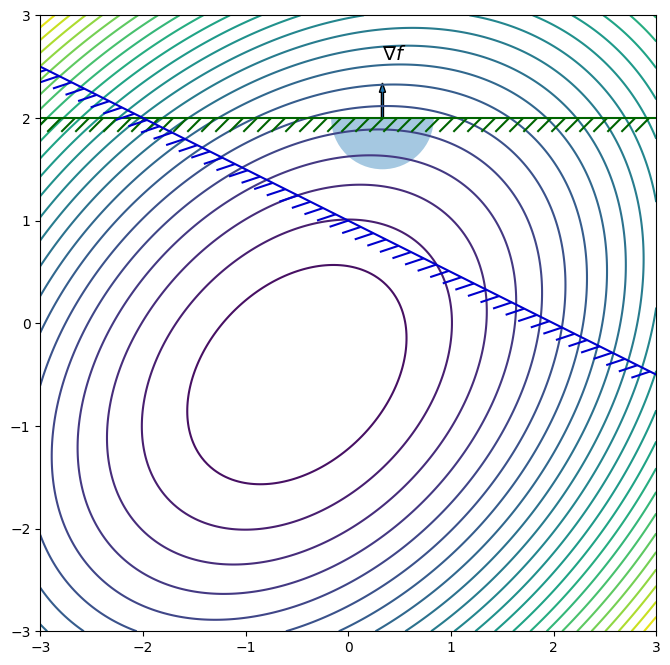

In [3]:
def f1(x):
    return 1.5*(x[0]**2 + x[1]**2) - x[0] * x[1] + x[0] + x[1]

def grad_f1(x):
    return np.array([3.0 * x[0] - x[1] + 1.0, 3.0 * x[1] - x[0] + 1.0])

def c1(x):
    return 2.0 - x[1]

def c2(x):
    return 2 - x[0] - 2 * x[1]

x0 = np.array([1.0/3.0, 2.0])
fig, ax = plot_contour(f1, xlow=-3, xhigh=3, ylow=-3, yhigh=3)
plot_descent(x0, grad_f1(x0), ax)
plot_constraint(ax, c1, colors='darkgreen',
                xlow=-3, xhigh=3, ylow=-3, yhigh=3)
plot_constraint(ax, c2, colors='mediumblue',
                xlow=-3, xhigh=3, ylow=-3, yhigh=3)

### Constraint qualification failures

Do the KKT conditions work for any set of constraints?
Consider the optimization problem:

\begin{equation*}
\begin{aligned}
\min \qquad & x_2 \\
\text{such that} \qquad & x_{2} - x_{1}^{2} \le 0\\ 
& \frac{1}{2} x_{1}^{2} - x_{2} \le 0 \\
\end{aligned}
\end{equation*}

In this example, the constrained minimizer is at $x^{*} = (0, 0)$.
At this point the gradients are

\begin{equation*}
\nabla f(x^{*}) = \begin{bmatrix} 0 \\ 1 \end{bmatrix} \qquad
\nabla c_{1}(x^{*}) = \begin{bmatrix} 0 \\ 1 \end{bmatrix} \qquad 
\nabla c_{2}(x^{*}) = \begin{bmatrix} 0 \\ -1 \end{bmatrix}
\end{equation*}

The KKT conditions give the following equations

\begin{equation*}
\begin{bmatrix}0 \\ 1 \end{bmatrix}
= - \lambda_{1} \begin{bmatrix} 0 \\ 1 \end{bmatrix} - \lambda_{2} \begin{bmatrix}0 \\ -1 \end{bmatrix}
\end{equation*}

This gives the equation $1 + \lambda_{1} - \lambda_{2} = 0$, which has no unique solution.

Consider the following constrained optimization problem:

\begin{equation*}
\begin{aligned}
\min \qquad & x_1 + x_2 \\
\text{such that} \qquad & - x_{2} \le 0 \\
& x_{2} - x_{1}^3 \le 0\\ 
\end{aligned}
\end{equation*}

In this problem we have that $x^{*} = (0, 0)$ is a constrained minimizer.

In this case, the objective and constraint gradients are the following at the minimizer:

\begin{equation*}
\nabla f(x^{*}) = \begin{bmatrix} 1 \\ 1 \end{bmatrix} \qquad
\nabla c_{1}(x^{*}) = \begin{bmatrix} 0 \\ -1 \end{bmatrix} \qquad 
\nabla c_{2}(x^{*}) = \begin{bmatrix} 0 \\ 1 \end{bmatrix}
\end{equation*}

As a result, the KKT conditions are

\begin{equation*}
\begin{bmatrix} 1 \\ 1 \end{bmatrix}
= - \lambda_{1} \begin{bmatrix} 0 \\ -1 \end{bmatrix} 
- \lambda_{2} \begin{bmatrix}0 \\ 1 \end{bmatrix}
\end{equation*}

This equation has no solutions since $0 = 1$ is nonsense. 
Therefore, we do not have a KKT point that satisfies $\nabla f = -A^{T}\lambda$.

What happend?
In both cases, the constraints have curvature that is not reflected in the linearization of the constraints.

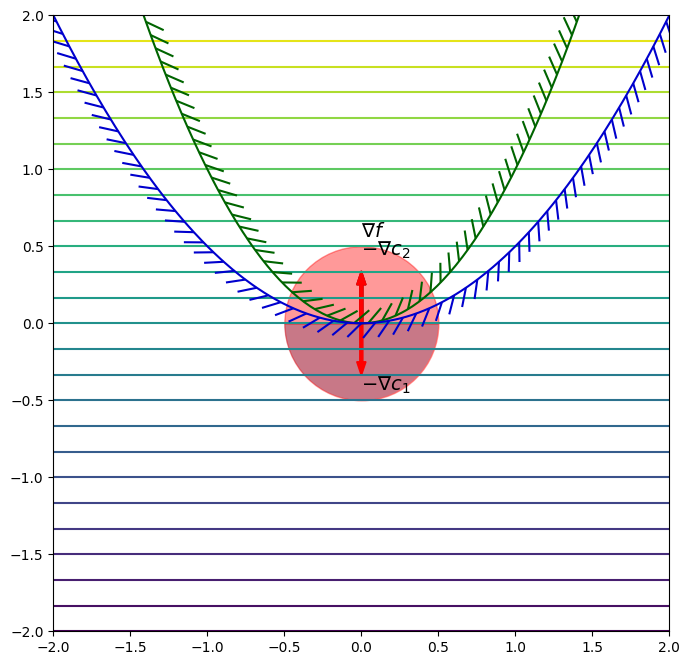

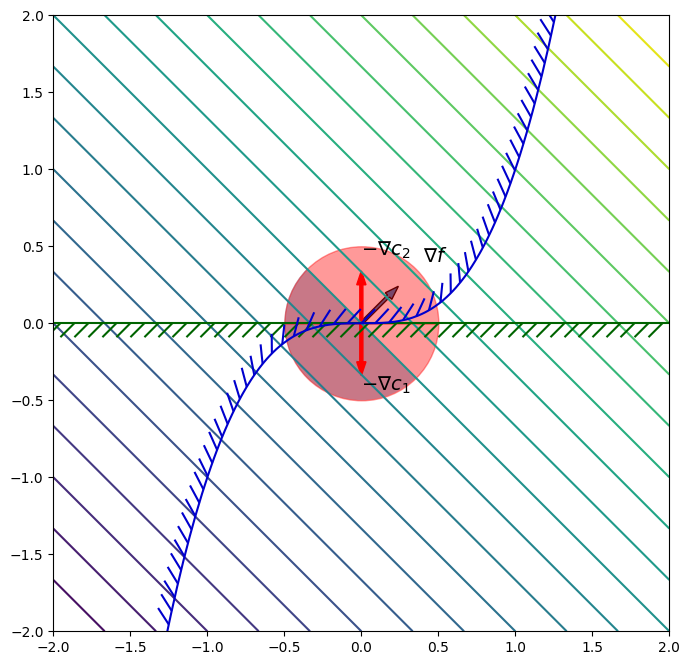

In [4]:
def f1(x):
    return x[1]

def grad_f1(x):
    return np.array([0.0, 1.0])

x0 = [0, 0]
fig, ax = plot_contour(f1)
plot_descent(x0, grad_f1(x0), ax)
plot_feasible(x0, np.array([0, 1.0]), ax, index=1)
plot_feasible(x0, np.array([0, -1.0]), ax, index=2)
plot_constraint(ax, lambda x: x[1] - x[0]**2, colors='darkgreen')
plot_constraint(ax, lambda x: 0.5*x[0]**2 - x[1], colors='mediumblue')

def f2(x):
    return x[0] + x[1]

def grad_f2(x):
    return np.array([1.0, 1.0])

x0 = [0, 0]
fig, ax = plot_contour(f2)
plot_descent(x0, grad_f2(x0), ax)
plot_feasible(x0, np.array([0, 1.0]), ax, index=1)
plot_feasible(x0, np.array([0, -1.0]), ax, index=2)
plot_constraint(ax, lambda x: -x[1], colors='darkgreen')
plot_constraint(ax, lambda x: x[1] - x[0]**3, colors='mediumblue')

plt.show()

### Linear independence constraint qualification (LICQ)

LICQ holds at $x^{*}$ if $c(x^{*}) \le 0$ and the active constraint gradients $\nabla c_{i}(x^{*})$ for $i \in
\mathcal{A}(x^{*})$ are linearly independent.

Linear independence of the active set of constraints at $x^{*}$:
 
\begin{equation*}
\sum_{i \in \mathcal{A}(x^{*})} a_{i} \nabla c_{i}(x^{*}) = 0 \qquad \implies a_{i} = 0
\end{equation*}

LICQ implies that the Lagrange multipliers $\lambda^{*}$ are unique.
This is easy to observe. Consider that at the KKT point $x^{*}$, LICQ holds.
Then from the first KKT condition

\begin{equation*}
\begin{aligned}
\nabla f(x^{*}) &= - A(x^{*})^{T} \lambda^{*} \\
A(x^{*}) \nabla f(x^{*}) &= - A(x^{*}) A(x^{*})^{T} \lambda^{*}
\end{aligned}
\end{equation*}

As a result, the unique multipliers are given by
\begin{equation*}
\lambda^{*} = - (A(x^{*}) A(x^{*})^{T} )^{-1} A(x^{*}) \nabla f(x^{*})
\end{equation*}
Due to LICQ the matrix $A(x^{*}) A(x^{*})^{T}$ has full rank.

Note that LICQ fails in the two examples shown above since the constraint gradients are linearly dependent.

### Advanced topics: Mangasarian-Fromovitz constraint qualification (MFCQ)

LICQ is the easiest to check, but is not the least restrictive constraint qualification.
Look at the following example?

\begin{equation*}
\begin{aligned}
\min \qquad & x_1 - x_2 \\
\qquad \text{such that} \qquad 
& -x_{1} \le 0 \\
& -x_{2} \le 0 \\
& x_1^2 + 4x_2^2 - 4 \le 0 \\
& (x_1 - 2)^2 + x_2^2 - 5\le 0
\end{aligned}
\end{equation*}

MFCQ is more difficult to check but is a weaker requirement than LICQ. In this example there are three constraints that are active. LICQ cannot be satisfied because the constraints are linearly independent. The Lagrange multipliers are not unique in this case. However, MFCQ is satisfied.

MFCQ holds at $x^{*}$ if $c(x^{*}) \le 0$ and there exists some $d \in \mathbb{R}^{n}$ such that $- \nabla c_{i}(x^{*})^{T}d > 0$ for all $i \in \mathcal{A}(x^{*})$

MFCQ implies that the Lagrange multipliers $\lambda^{*}$ are bounded (but not necessarily unique).
Checking whether MFCQ holds requires solving a linear programming problem.

\begin{equation*}
\begin{aligned}
\min_{d, \theta} \qquad & - \theta \\
\text{such that} \qquad & 0 \le \theta \le 1 \\
& -\nabla c_{i}^{T} d \ge \theta \qquad i \in \mathcal{A}(x^{*}) \\
\end{aligned}
\end{equation*}
  
If there is a solution of this optimization problem then MFCQ is satisfied if $\theta = 1$ at the optimized point.


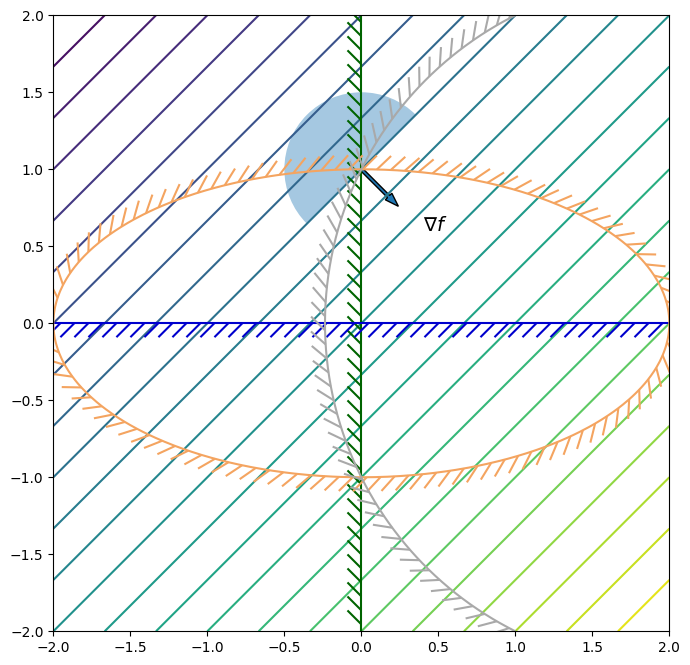

In [5]:
def f1(x):
    return x[0] - x[1]

def grad_f1(x):
    return np.array([1.0, -1.0])

def c1(x):
    return -x[0]

def c2(x):
    return -x[1]

def c3(x):
    return x[0]**2 + 4.0 * x[1]**2 - 4.0

def c4(x):
    return (x[0] - 2.0)**2 + x[1]**2 - 5.0

x0 = np.array([0.0, 1.0])

fig, ax = plot_contour(f1)
plot_descent(x0, grad_f1(x0), ax)
plot_constraint(ax, c1, colors='darkgreen')
plot_constraint(ax, c2, colors='mediumblue')
plot_constraint(ax, c3, colors='sandybrown')
plot_constraint(ax, c4, colors='darkgray')

## Second-order necessary conditions

To define the second-order necessary conditions for constrained optimality, we first have to define the Hessian matrix of the Lagrangian that takes the form

\begin{equation*}
H_{\mathcal{L}}(x, \lambda) = \nabla^2 \mathcal{L} = \nabla^2 f(x) + \sum_{i=1}^{m} \lambda_{i} \nabla^2 c_{i}(x)
\end{equation*}

* If $x^{*}$ is a local minimizer at which LICQ holds, then there are multipliers $\lambda^{*} \ge 0$, that satisfy $\nabla f(x^{*}) = - A(x^{*})^{T} \lambda^{*}$ and $c_{i}(x^{*}) \lambda^{*}_{i} = 0$ and

\begin{equation*}
d^{T} H_{\mathcal{L}}(x^{*}, \lambda^{*}) d \ge 0 \qquad \text{for} \qquad d^{T} \nabla c_{i}(x^{*}) = 0 \;\; i \in \mathcal{A}(x^{*})
\end{equation*}

This raises an important apsect of constrained optimization algorithms: You can work with the so-called reduced Hessian matrix.

Let $Z$ be a basis for the null space of the active constraint gradients:

\begin{equation*}
\nabla c_{i}(x^{*})^{T} Z = 0 \qquad \text{for all} \;\; i \in \mathcal{A}(x^{*})
\end{equation*}

The matrix

\begin{equation*}
Z^{T} H_{\mathcal{L}}(x^{*}, \lambda^{*}) Z
\end{equation*}

is called the reduced Hessian.

## Second-order sufficient conditions

There are different types of sufficient conditions for constrained optimization.
Different versions have weaker conditions than the second-order sufficient conditions stated here.

* The point $x^{*}$ is a constrained minimizer if

1. $x^{*}$ is a feasible point where LICQ holds
2. There are multipliers $\lambda^{*} \ge 0$, that satisfy $\nabla f(x^{*}) = - A(x^{*})^{T} \lambda^{*}$ and $c_{i}(x^{*}) \lambda^{*}_{i} = 0$
3. Strict complementarity holds such that $\lambda_{i}^{*} > 0$ for $i \in \mathcal{A}(x^{*})$
4. There exists some $\omega > 0$ such that

\begin{equation*}
d^{T} H_{\mathcal{L}}(x^{*}, \lambda^{*}) d \ge \omega ||d||_{2}^{2} \qquad \text{for}  \qquad - d^{T} \nabla c_{i}(x^{*}) = 0 \;\; i \in \mathcal{A}(x^{*})
\end{equation*}

The advantage of these conditions is that they can be verified computationally in a relatively straightforward manner.
LICQ can be checked via a QR decomposition or singular value decomposition of the matrix of active constraint gradients.
The KKT conditions can be verified and the final requirement is a condition that the reduced Hessian matrix be positive definite.
This check can also be implemented computationally in a straightforward manner, if the full Hessian matrix of the objective and constraints is available.